## Quick start
After cloning the repository, the package may be installed with `pip` in the regular way. From the repository root run:

```bash
pip install .
```
The following code plots a two dimensional density slice.

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


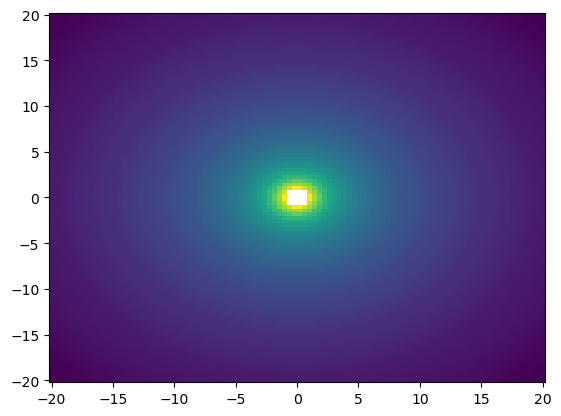

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from starwinds_readplt.dataset import Dataset
from batcamp import Octree, OctreeInterpolator

# Read the dataset
ds = Dataset.from_file("../example_data/3d__var_4_n00000000.plt")

# Create the octree and interpolator
tree = Octree.from_dataset(ds, coord_system="rpa")
interp = OctreeInterpolator(ds, ["Rho [g/cm^3]"], tree=tree)

# Create a grid of points and interpolate the density
X, Y = np.meshgrid(np.linspace(-20, 20, 100), np.linspace(-20, 20, 100))
Z = np.zeros_like(X)
rho = interp(X, Y, Z)
plt.pcolormesh(X, Y, rho, norm="log")